In [22]:
fname = "/mnt/d/python-projects/pr_calcium-git/caiman_motion/data/niels_video.avi"
framerate = 5

In [ ]:
# Auto-Reload of .py files
%reload_ext autoreload

import caiman_analysis as cma
m_orig = cma.load_video(fname=fname, fframe=framerate, play_movies=False, downsample_ratio=1, resize=False)

In [77]:
# Create a motion correction object with parameters for analysis
max_shifts = (12, 12) #(6, 6)  # maximum allowed rigid shift in pixels (view the movie to get a sense of motion)
strides =  (96, 96) #(48, 48)  # create a new patch every x pixels for pw-rigid correction
overlaps = (48, 48) #(24, 24)  # overlap between patches (size of patch strides+overlaps)
max_deviation_rigid = 6 #3   # maximum deviation allowed for patch with respect to rigid shifts
pw_rigid = False  # flag for performing rigid or piecewise rigid motion correction
shifts_opencv = True  # flag for correcting motion using bicubic interpolation (otherwise FFT interpolation is used)
border_nan = 'copy'  # replicate values along the boundary (if True, fill in with NaN)

In [ ]:
# Run motion correction
m_corr, m_rig_corr = cma.run_motioncorrect(fname=fname, max_shifts=max_shifts, strides=strides, overlaps=overlaps, max_deviation_rigid=max_deviation_rigid,
              shifts_opencv=shifts_opencv, downsample_ratio=1, nonneg_movie=True, border_nan=border_nan, save_movie=True, pw_rigid = True)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Export of the file as .avi / .nwb / .tif
m_orig.save(file_name='/mnt/d/python-projects/pr_calcium-git/caiman_motion/data/niels_video_motion_corrected.avi', 
            q_min=0.0, 
            q_max=252.0, 
            sess_desc="...")

/home/niels/miniforge3/envs/caiman/lib/python3.12/site-packages/caiman/base/timeseries.py:345: FutureWarning: Device.__init__: Using positional arguments for this method is discouraged and will be deprecated in a future major release. Please use keyword arguments to ensure future compatibility.
  device = Device('imaging_device')
/home/niels/miniforge3/envs/caiman/lib/python3.12/site-packages/caiman/base/timeseries.py:348: FutureWarning: OpticalChannel.__init__: Using positional arguments for this method is discouraged and will be deprecated in a future major release. Please use keyword arguments to ensure future compatibility.
  optical_channel = OpticalChannel('OpticalChannel', 'main optical channel', emission_lambda=emission_lambda)


'/mnt/d/python-projects/pr_calcium-git/caiman_motion/data/niels_video_motion_corrected.nwb'

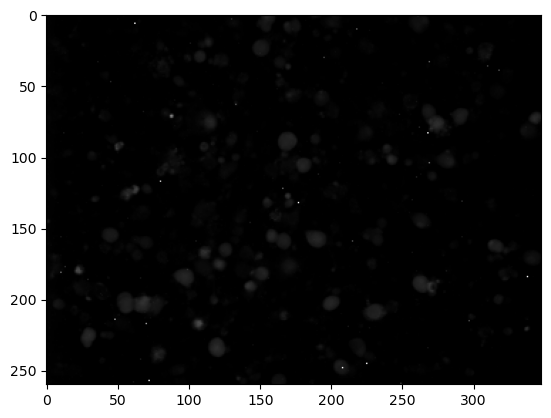

In [90]:
video = np.array(m_orig)  # shape: (T, H, W)
video_mean = video.mean(axis=0) # shape: (H, W)

plt.imshow(video_mean, cmap='gray')
plt.show()
